In [ ]:
import pandas as pd
import numpy as np




Dataset from kaggle : e comerce behaviour dataset

In [ ]:
df = pd.read_csv("/content/ecommerce_customer_churn_dataset.csv")

In [ ]:
df.head () #DISPLAY FIRST 5 ROWS

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Exploratory Data Analysis (EDA)

The purpose of EDA is to:

Understand customer behavior Discover churn patterns Identify high-value customer characteristics Select features for ML models


In [ ]:
df.shape #how many rows and columns do we have

(50000, 25)

In [ ]:
df.info() # how many columns we have , what kind of data we have and how many  not null data in a column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [ ]:
df.isnull().sum() #to check data frame has how many null values in each column

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [ ]:
df.duplicated().sum() # how many duplicated row are there in data frame

np.int64(0)

In [ ]:
df['Churned'].value_counts() #how many records of the categorical value we have in the dataset

,count
Churned,
0,35550
1,14450


Cleaning Dataset


In [ ]:
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(include='float64').columns
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [ ]:
df = df[df['Age'] >= 18]
df = df[df['Age'] <= 90]
df = df[df['Total_Purchases'] >= 0]
df['Cart_Abandonment_Rate'] = df['Cart_Abandonment_Rate'].clip(upper=100)
print("Shape after fixing outliers:", df.shape)

Shape after fixing outliers: (49910, 25)


Churn Distribution



In [ ]:
import seaborn as sns    #these are the python libraries for plotting the graph
import matplotlib.pyplot as plt



/tmp/ipykernel_5190/836596312.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=df,


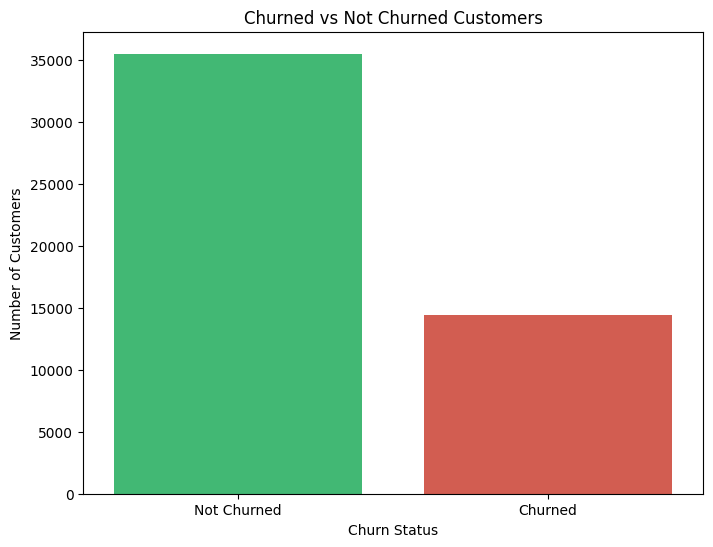

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='Churned', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churned vs Not Churned Customers')
plt.xticks([0,1], ['Not Churned', 'Churned'])
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

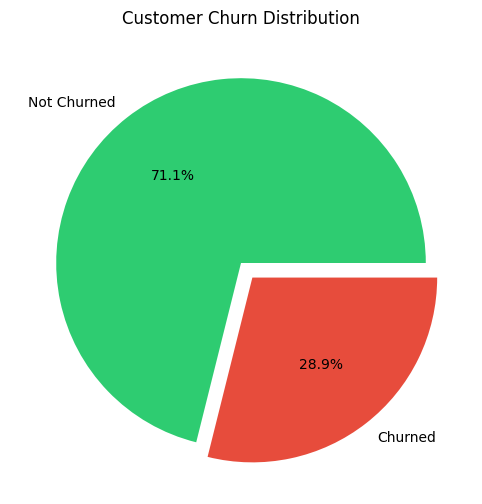

In [ ]:
plt.figure(figsize=(8,6))
df['Churned'].value_counts().plot(
    kind='pie',
    labels=['Not Churned', 'Churned'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=(0, 0.1)
)
plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

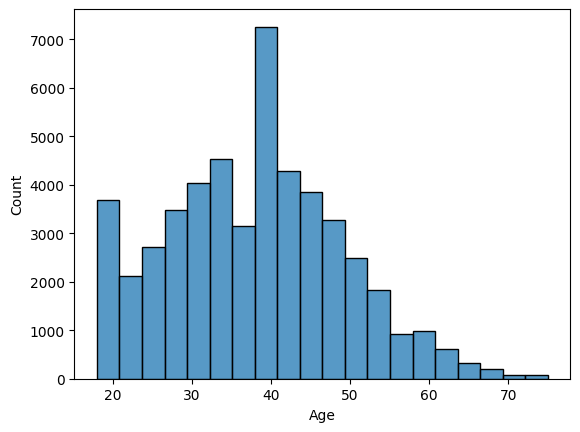

In [ ]:
sns.histplot(df['Age'], bins=20)

<Axes: xlabel='Gender', ylabel='count'>

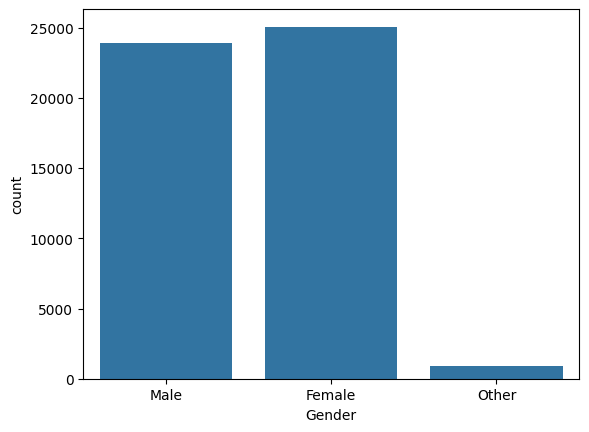

In [ ]:
sns.countplot(x='Gender', data=df)


<Axes: xlabel='Login_Frequency', ylabel='Count'>

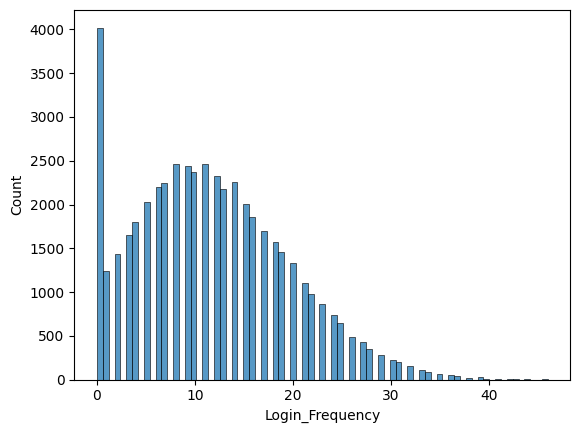

In [ ]:
sns.histplot(df['Login_Frequency'])


<Axes: xlabel='Session_Duration_Avg', ylabel='Count'>

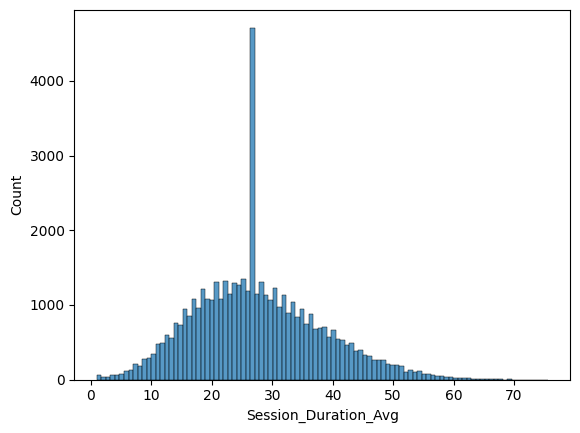

In [ ]:
sns.histplot(df['Session_Duration_Avg'])

<Axes: xlabel='Email_Open_Rate', ylabel='Count'>

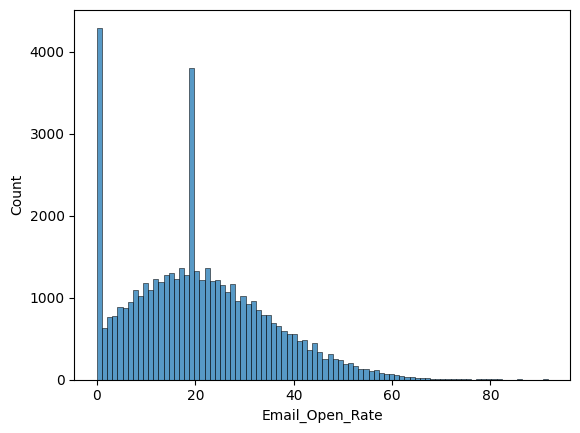

In [ ]:
sns.histplot(df['Email_Open_Rate'])

High-Value Customer Analysis

In [ ]:
df['High_Value_Customer'] = (
    df['Lifetime_Value']
    >= df['Lifetime_Value'].quantile(0.80)
).astype(int)

In [ ]:

df['High_Value_Customer'].value_counts()

,count
High_Value_Customer,
0,39928
1,9982


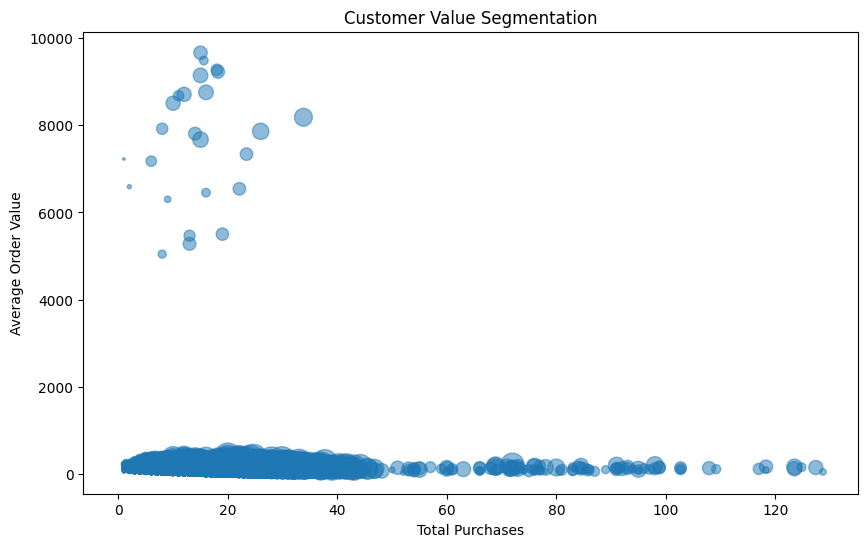

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Total_Purchases'],
    df['Average_Order_Value'],
    s=df['Lifetime_Value']/20,
    alpha=0.5
)

plt.xlabel('Total Purchases')
plt.ylabel('Average Order Value')
plt.title('Customer Value Segmentation')
plt.show()

In [ ]:
df['Customer_Tier'] = pd.qcut(
    df['Lifetime_Value'],
    q=4,
    labels=[
        'Bronze',
        'Silver',
        'Gold',
        'Platinum'
    ]
)

In [ ]:
df.groupby('Customer_Tier').agg({
    'Lifetime_Value':'mean',
    'Total_Purchases':'mean',
    'Average_Order_Value':'mean',
    'Churned':'mean'
}).round(2)

/tmp/ipykernel_5190/783989664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Customer_Tier').agg({


,Lifetime_Value,Total_Purchases,Average_Order_Value,Churned
Customer_Tier,,,,
Bronze,531.66,7.29,94.95,0.41
Silver,1009.66,11.47,108.57,0.20
Gold,1530.01,14.72,128.52,0.14
Platinum,2690.17,19.04,160.36,0.40


/tmp/ipykernel_5190/2691577822.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Customer_Tier')['Churned']


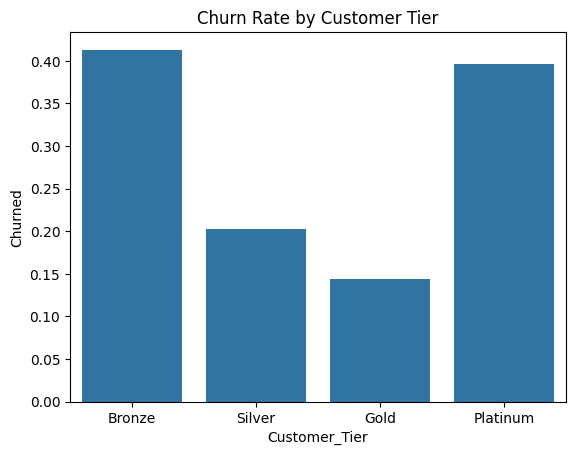

In [ ]:
tier_churn = (
    df.groupby('Customer_Tier')['Churned']
      .mean()
      .reset_index()
)

sns.barplot(
    data=tier_churn,
    x='Customer_Tier',
    y='Churned'
)

plt.title('Churn Rate by Customer Tier')
plt.show()

In [ ]:
df['Customer_Tier'].value_counts()


,count
Customer_Tier,
Bronze,12478
Platinum,12478
Silver,12477
Gold,12477


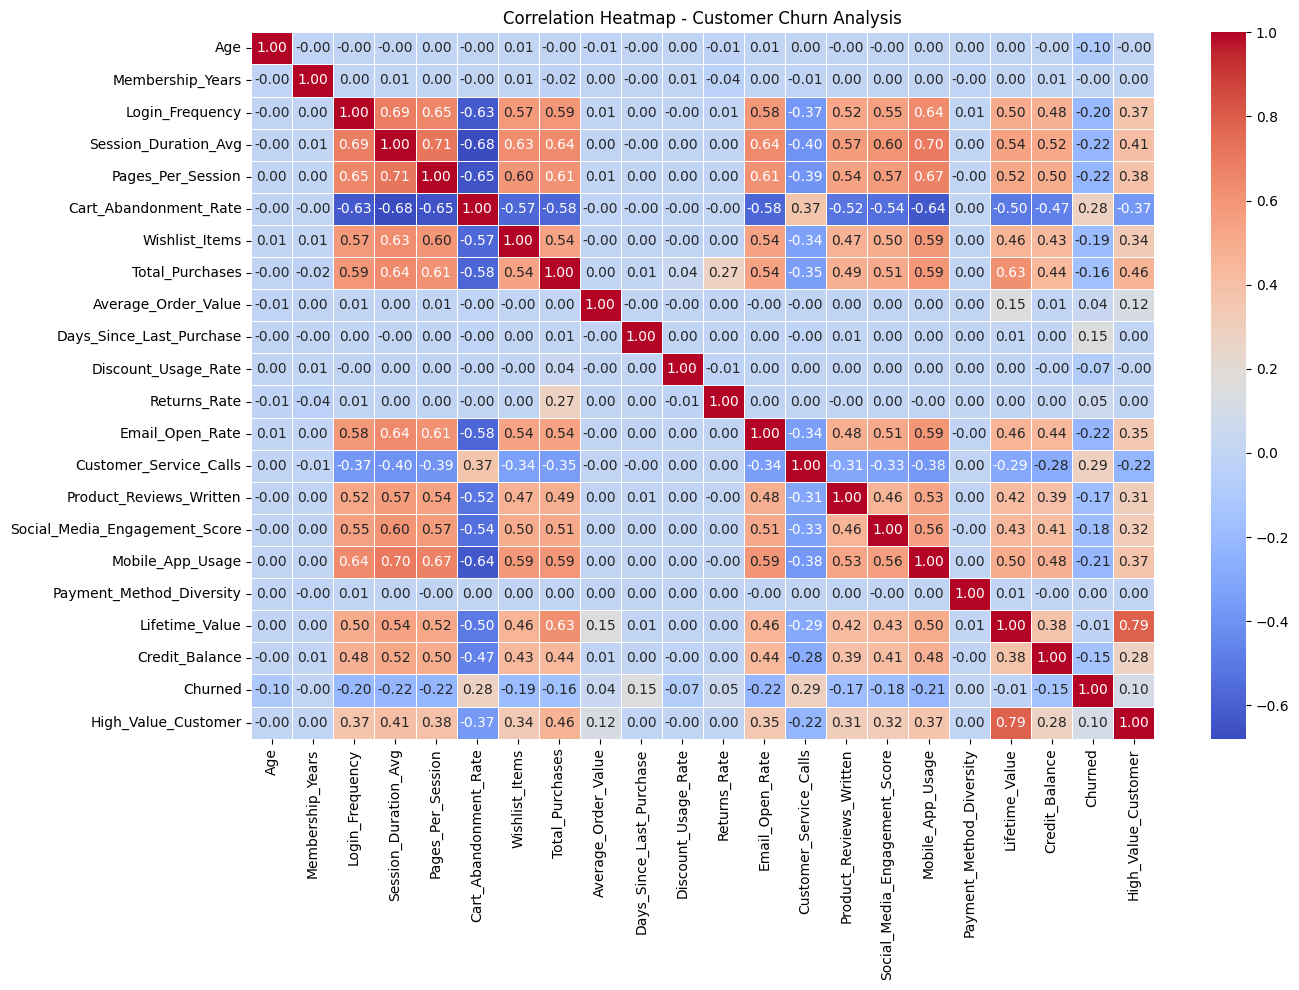

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr,
            annot=True,      # shows numbers inside each square
            cmap='coolwarm', # red/blue colour scheme
            fmt='.2f',       # rounds numbers to 2 decimal places
            linewidths=0.5)  # adds lines between squares

plt.title('Correlation Heatmap - Customer Churn Analysis')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Gender','Country','City','Signup_Quarter','Customer_Tier']:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,High_Value_Customer,Customer_Tier
0,43.0,1,2,21,2.9,14.0,27.4,6.0,50.6,3.0,...,4.0,16.3,20.8,1.0,953.33,2278.0,0,0,0,3
1,36.0,1,6,20,1.6,15.0,42.7,10.3,37.7,1.0,...,3.0,27.6,23.3,3.0,1067.47,3028.0,0,3,0,3
2,45.0,0,1,38,2.9,10.0,24.8,1.6,70.9,1.0,...,1.0,27.6,8.8,2.0,1289.75,2317.0,0,3,0,1
3,56.0,0,7,27,2.6,10.0,38.4,14.8,41.7,9.0,...,5.0,85.9,31.0,3.0,2340.92,2674.0,0,0,1,2
4,35.0,1,4,9,3.1,29.0,51.4,8.4,19.1,9.0,...,11.0,83.0,50.4,4.0,3041.29,5354.0,0,3,1,2


Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churned'], axis=1)
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (39928, 26)
Testing set size: (9982, 26)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8012422360248447
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      7098
           1       0.73      0.50      0.59      2884

    accuracy                           0.80      9982
   macro avg       0.77      0.71      0.73      9982
weighted avg       0.79      0.80      0.79      9982



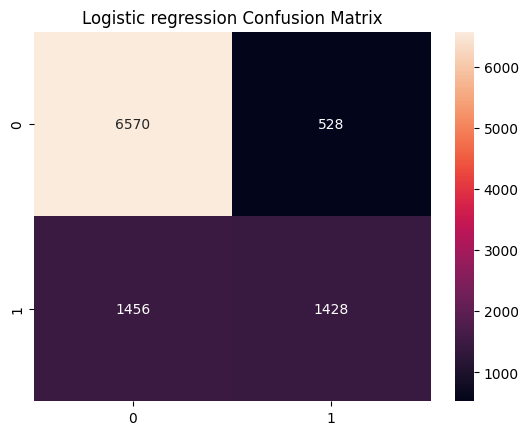

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Logistic regression Confusion Matrix')
plt.show()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9157483470246444
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7098
           1       0.92      0.78      0.84      2884

    accuracy                           0.92      9982
   macro avg       0.92      0.87      0.89      9982
weighted avg       0.92      0.92      0.91      9982



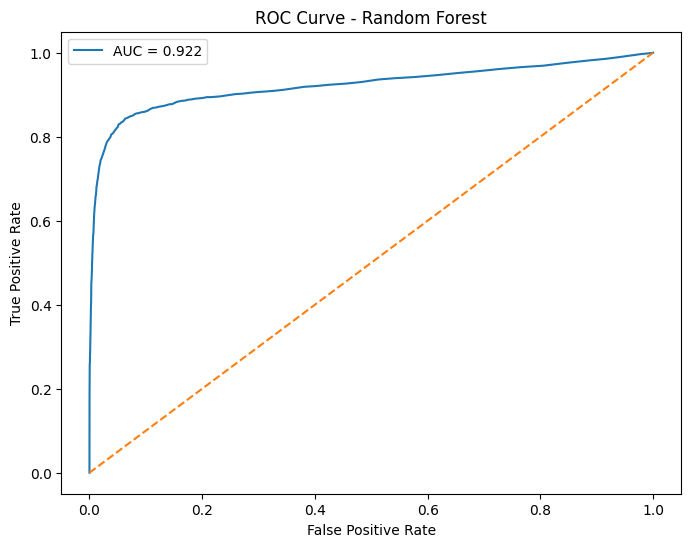

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

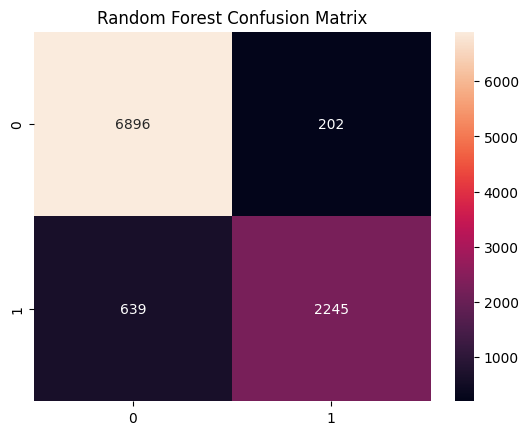

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Random Forest Confusion Matrix')
plt.show()

Gradient Boosting Accuracy: 0.9174514125425767

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      7098
           1       0.93      0.78      0.84      2884

    accuracy                           0.92      9982
   macro avg       0.92      0.88      0.89      9982
weighted avg       0.92      0.92      0.92      9982



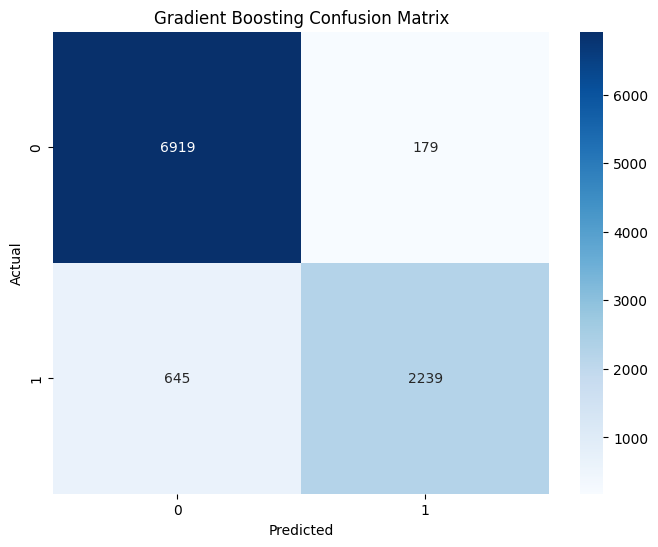

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_gbc = gbc.predict(X_test_scaled)

# Evaluate the model
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gbc))
print("\nGradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gbc))

# Confusion Matrix
cm_gbc = confusion_matrix(y_test, y_pred_gbc)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_gbc,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

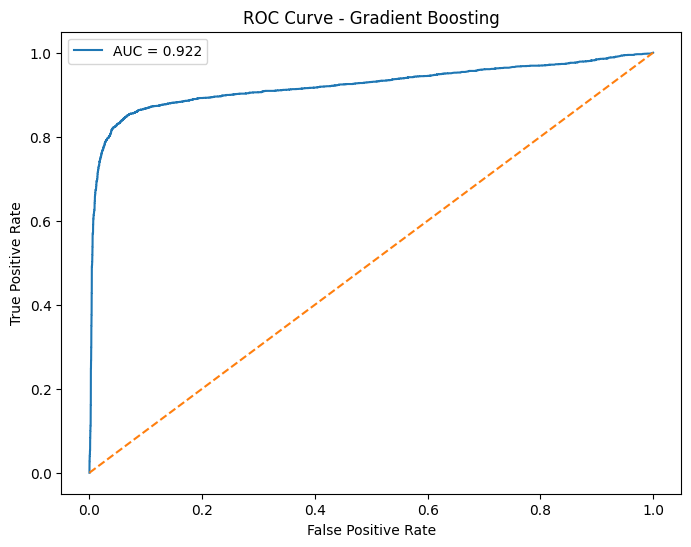

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = gbc.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.show()

Decision Tree Accuracy: 0.8438188739731517

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89      7098
           1       0.72      0.74      0.73      2884

    accuracy                           0.84      9982
   macro avg       0.81      0.81      0.81      9982
weighted avg       0.85      0.84      0.84      9982



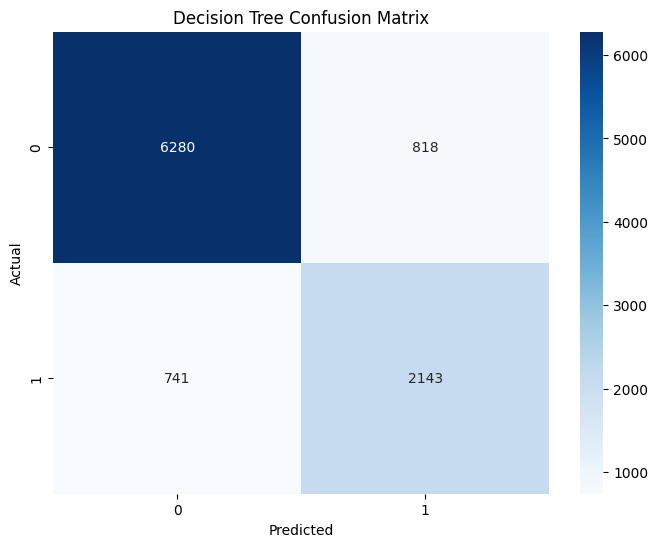

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_dtc = dtc.predict(X_test_scaled)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dtc))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dtc))

# Confusion Matrix
cm_dtc = confusion_matrix(y_test, y_pred_dtc)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_dtc,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Model Accuracy Comparison:
                 Model  Accuracy
2    Gradient Boosting  0.917451
1        Random Forest  0.915748
3        Decision Tree  0.843819
0  Logistic Regression  0.801242


/tmp/ipykernel_5190/2691129679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


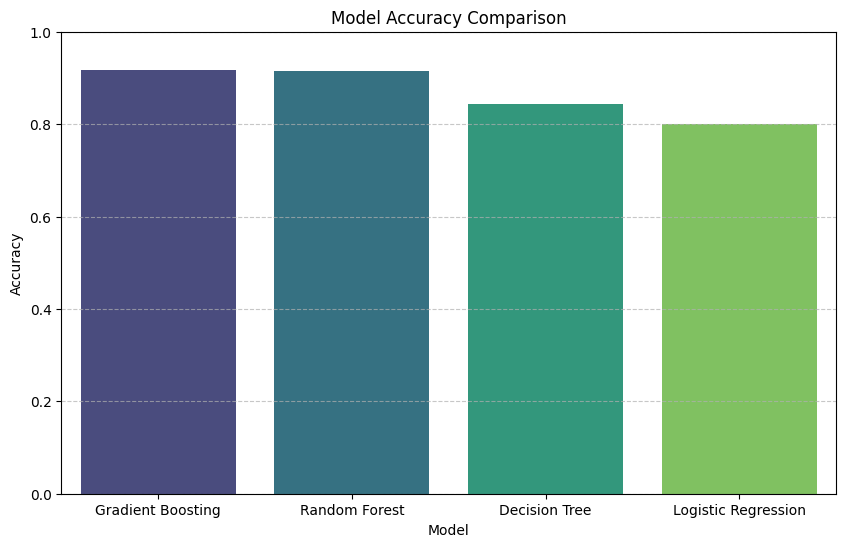

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Collect accuracy scores
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gbc),
    'Decision Tree': accuracy_score(y_test, y_pred_dtc)
}

# Create a DataFrame for comparison
accuracy_df = pd.DataFrame(accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Accuracy Comparison:")
print(accuracy_df)

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Model Performance Comparison:
                     Accuracy  Precision    Recall  F1-Score
Gradient Boosting    0.917451   0.925972  0.776352  0.844587
Random Forest        0.915748   0.917450  0.778433  0.842243
Decision Tree        0.843819   0.723742  0.743065  0.733276
Logistic Regression  0.801242   0.730061  0.495146  0.590083


/tmp/ipykernel_5190/3528739752.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y='F1-Score', data=comparison_df.sort_values(by='F1-Score', ascending=False), palette='magma')


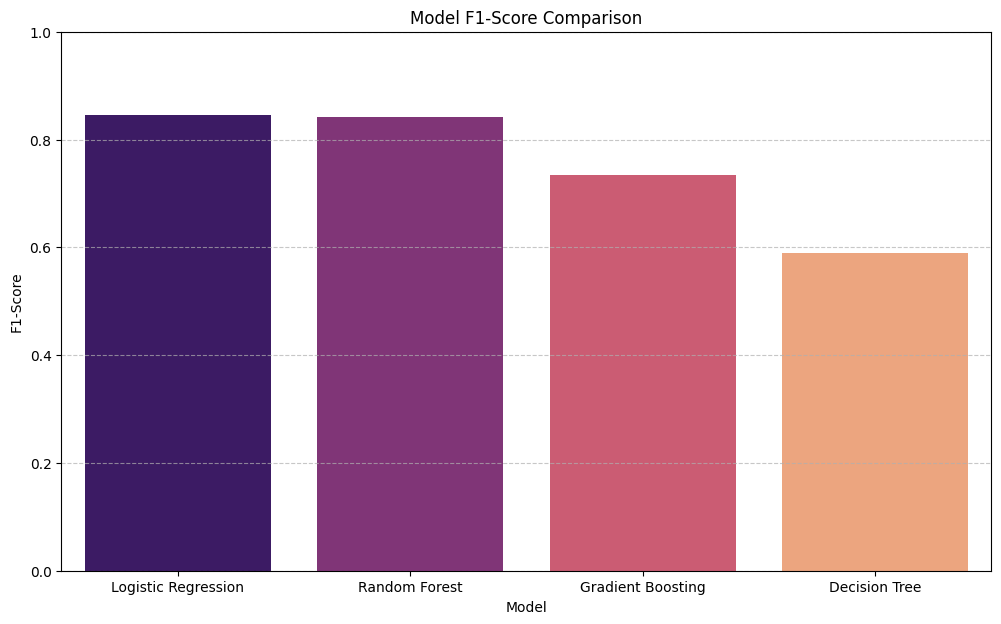

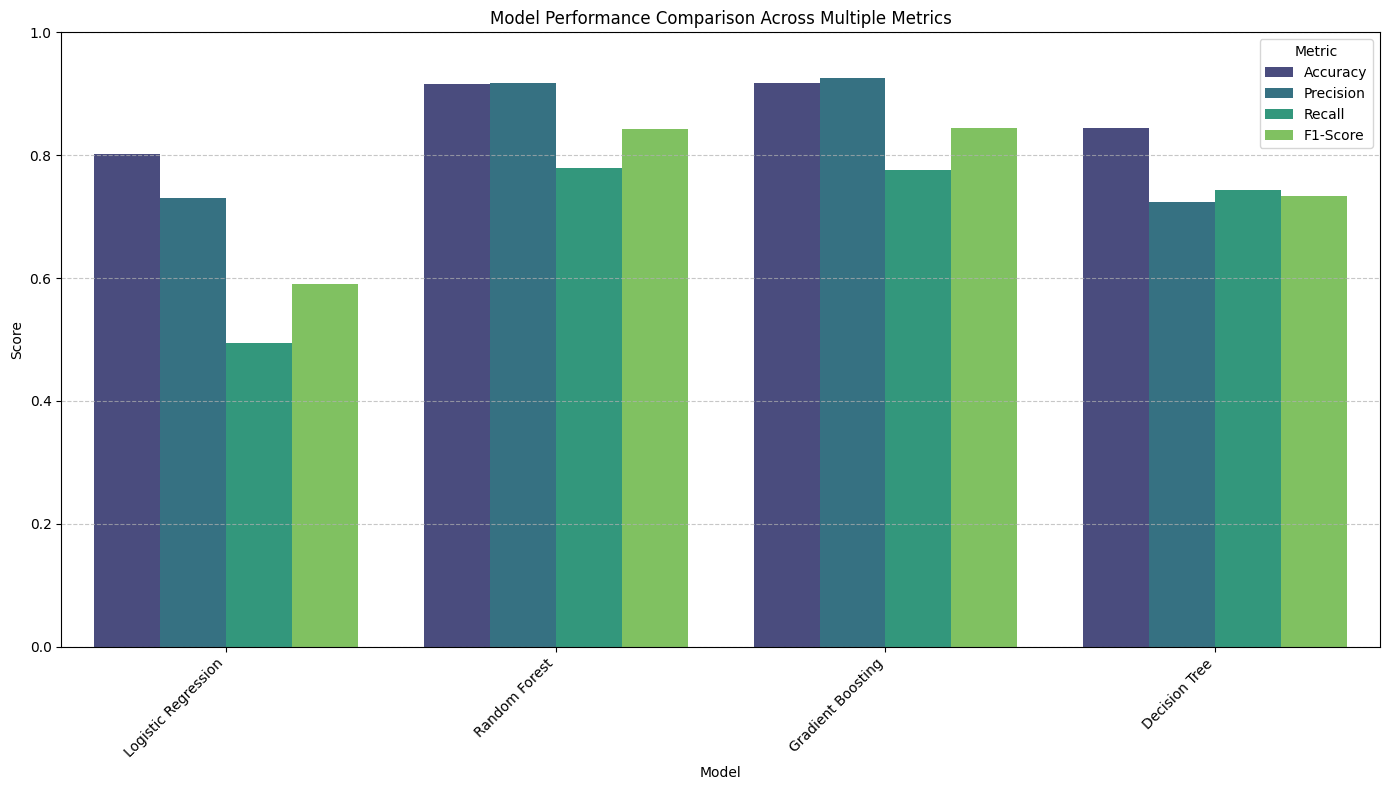

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics for each model
metrics = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1-Score': f1_score(y_test, y_pred_lr)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf)
    },
    'Gradient Boosting': {
        'Accuracy': accuracy_score(y_test, y_pred_gbc),
        'Precision': precision_score(y_test, y_pred_gbc),
        'Recall': recall_score(y_test, y_pred_gbc),
        'F1-Score': f1_score(y_test, y_pred_gbc)
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dtc),
        'Precision': precision_score(y_test, y_pred_dtc),
        'Recall': recall_score(y_test, y_pred_dtc),
        'F1-Score': f1_score(y_test, y_pred_dtc)
    }
}

# Create a DataFrame from the metrics
comparison_df = pd.DataFrame(metrics).T # .T transposes the DataFrame

print("\nModel Performance Comparison:")
print(comparison_df.sort_values(by='F1-Score', ascending=False))

# Plotting the F1-Score comparison
plt.figure(figsize=(12, 7))
sns.barplot(x=comparison_df.index, y='F1-Score', data=comparison_df.sort_values(by='F1-Score', ascending=False), palette='magma')
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plotting all metrics
comparison_df_melted = comparison_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
plt.figure(figsize=(14, 8))
sns.barplot(x='index', y='Score', hue='Metric', data=comparison_df_melted, palette='viridis')
plt.title('Model Performance Comparison Across Multiple Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 Model Performance Analysis

Four ML models were trained and evaluated on the e-commerce customer churn dataset:

- **Gradient Boosting** achieved the highest accuracy of **91.74%** — boosting algorithms iteratively correct errors of previous learners, making it the strongest model.
- **Random Forest** closely followed at **91.57%** — ensemble of multiple decision trees capturing complex patterns.
- **Decision Tree** achieved **84.38%** — lower accuracy but highly interpretable for business stakeholders.
- **Logistic Regression** scored **80.12%** — serves as the baseline, confirming churn patterns are non-linear.

**Gradient Boosting is selected as the best model** for churn prediction due to its superior predictive performance.

Feature Importance Analysis

Why are customers churning?

This is often more valuable to management than accuracy itself.

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbc.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                     Feature  Importance
21            Lifetime_Value    0.309778
8      Cart_Abandonment_Rate    0.175127
13       Discount_Usage_Rate    0.119748
16    Customer_Service_Calls    0.107439
12  Days_Since_Last_Purchase    0.063423
0                        Age    0.052885
10           Total_Purchases    0.049034
15           Email_Open_Rate    0.045274
6       Session_Duration_Avg    0.016632
7          Pages_Per_Session    0.013234
14              Returns_Rate    0.012889
9             Wishlist_Items    0.011733
19          Mobile_App_Usage    0.008204
5            Login_Frequency    0.008061
17   Product_Reviews_Written    0.004367


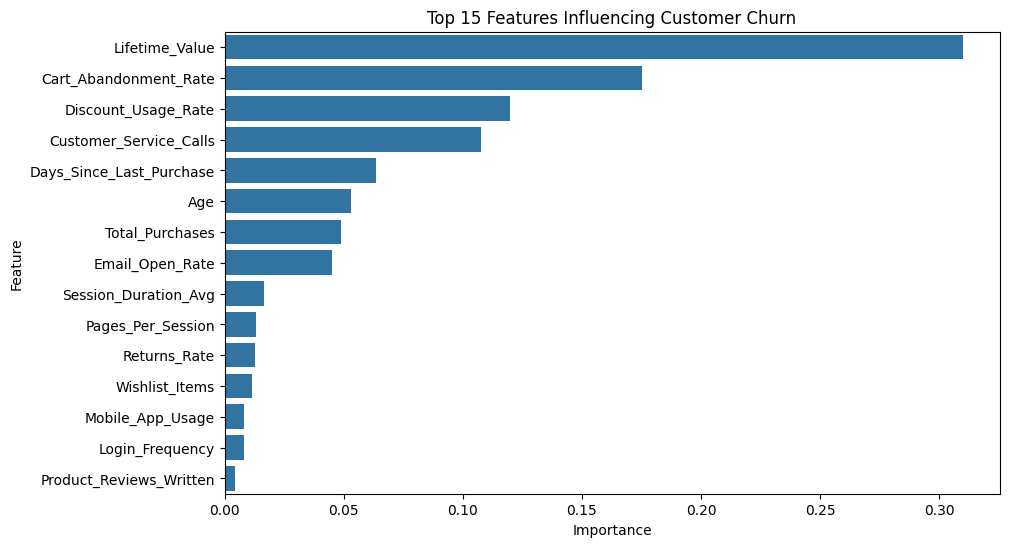

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Features Influencing Customer Churn')

plt.show()

In [ ]:
import pandas as pd

X_scaled_full = scaler.transform(X)
y_pred_full = gbc.predict(X_scaled_full)

# Reset index for alignment
X_df = pd.DataFrame(X).reset_index(drop=True)
y_series = pd.Series(y).reset_index(drop=True)
preds_series = pd.Series(y_pred_full).reset_index(drop=True)

# Combine into final DataFrame
final_df = pd.concat([X_df, y_series, preds_series], axis=1)

# Rename columns
final_df.columns = list(X_df.columns) + ['Actual_Target', 'Predicted_Result']

print(final_df.shape)
final_df.head()

(49910, 28)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Signup_Quarter,High_Value_Customer,Customer_Tier,Actual_Target,Predicted_Result
0,43.0,1,2,21,2.9,14.0,27.4,6.0,50.6,3.0,...,16.3,20.8,1.0,953.33,2278.0,0,0,3,0,0
1,36.0,1,6,20,1.6,15.0,42.7,10.3,37.7,1.0,...,27.6,23.3,3.0,1067.47,3028.0,3,0,3,0,0
2,45.0,0,1,38,2.9,10.0,24.8,1.6,70.9,1.0,...,27.6,8.8,2.0,1289.75,2317.0,3,0,1,0,0
3,56.0,0,7,27,2.6,10.0,38.4,14.8,41.7,9.0,...,85.9,31.0,3.0,2340.92,2674.0,0,1,2,0,0
4,35.0,1,4,9,3.1,29.0,51.4,8.4,19.1,9.0,...,83.0,50.4,4.0,3041.29,5354.0,3,1,2,0,0


In [ ]:
from google.colab import files
final_df.to_csv("cleaned_churn_data.csv",index= False)
files.download('cleaned_churn_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>